# Logistic Regression Project Report
## Diabetes Prediction using Kaggle Data

**Student:** AKASH DATTA  
**Date:** 03/10/2016 

### Objective
Predict `Outcome`: **0 = No diabetes, 1 = Diabetes**.

This notebook follows the supplied requirements: inspect the Kaggle CSV, replace invalid zeros, perform a train-test split, apply median imputation and scaling, train balanced Logistic Regression, evaluate the model, and interpret coefficients.

## 1. Dataset
The supplied Pima Indians Diabetes dataset contains eight predictors and one binary target. The CSV is read without a header because its first row is an actual observation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from pathlib import Path

file_path = "pima-indians-diabetes(1).csv"
columns = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age","Outcome"]
candidate_paths = [
    Path(file_path),                                
    Path.cwd() / file_path,                         
    Path(r"C:\Users\akash\Downloads") / file_path,  
]

resolved_path = next((p for p in candidate_paths if p.exists()), None)

if resolved_path is None:
    resolved_path = next((p for p in candidate_paths if p.exists()), None)

    if resolved_path is None:
        search_roots = [
            Path.cwd(),
            Path.home(),
            Path(r"C:\Users\akash\Downloads"),
            Path(r"C:\Users\akash\Desktop"),
            Path(r"C:\Users\akash\Documents"),
        ]

        matches = []
        for root in search_roots:
            if root.exists():
                matches.extend(root.rglob("pima-indians-diabetes*.csv"))
                matches.extend(root.rglob("*diabetes*.csv"))

        if matches:
            resolved_path = sorted(set(matches))[0]
        else:
            raise FileNotFoundError(
                f"Could not find '{file_path}'. Please place the CSV in the notebook folder, "
                "download it again, or update the path to the correct location."
            )

df = pd.read_csv(resolved_path, header=None, names=columns)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Data Inspection and Invalid-Zero Handling
Zero is treated as an invalid/missing measurement for Glucose, BloodPressure, SkinThickness, Insulin, and BMI. These values are replaced with NaN and later imputed with the median.

In [9]:
invalid_zero_cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
zero_counts = (df[invalid_zero_cols] == 0).sum().sort_values(ascending=False)
display(zero_counts.to_frame("Invalid zero count"))

X = df.drop(columns="Outcome").copy()
y = df["Outcome"].copy()
X[invalid_zero_cols] = X[invalid_zero_cols].replace(0, np.nan)
display(X.isna().sum().to_frame("Missing values after zero replacement"))

,Invalid zero count
Insulin,374
SkinThickness,227
BloodPressure,35
BMI,11
Glucose,5


,Missing values after zero replacement
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0


## 3. Train-Test Split and Model
The workflow is: **median imputation → StandardScaler → balanced Logistic Regression**. A stratified 80/20 split with `random_state=42` is used.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(class_weight="balanced", max_iter=1000))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 614
Testing samples: 154


## 4. Evaluation Metrics

In [11]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

results = pd.DataFrame({
    "Metric": ["Accuracy","Precision","Recall","F1-score","ROC-AUC"],
    "Result": [accuracy,precision,recall,f1,roc_auc]
})
results["Result"] = results["Result"].round(3)
display(results)

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:")
print(cm)

,Metric,Result
0,Accuracy,0.734
1,Precision,0.603
2,Recall,0.704
3,F1-score,0.650
4,ROC-AUC,0.813


Confusion matrix:
[[75 25]
 [16 38]]


## 5. Confusion Matrix

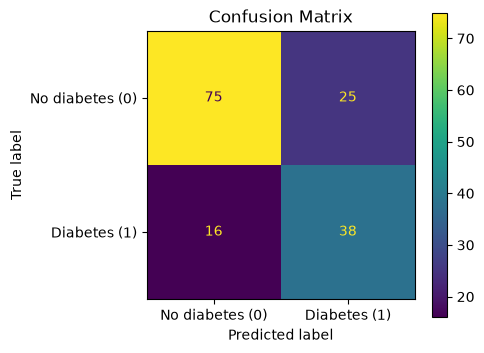

In [12]:
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No diabetes (0)","Diabetes (1)"]).plot(ax=ax)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

## 6. ROC Curve

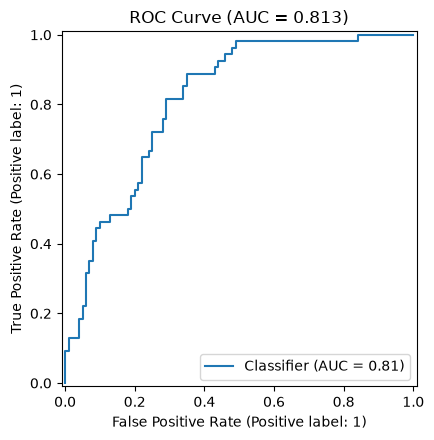

In [13]:
fig, ax = plt.subplots(figsize=(6,4.5))
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax)
ax.set_title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.tight_layout()
plt.show()

## 7. Coefficient Interpretation
Because the predictors are standardized, the coefficient signs show the direction of association in the fitted model. Positive coefficients increase the model's log-odds for Outcome = 1; negative coefficients decrease them.

,Feature,Coefficient
1,Glucose,1.1835
5,BMI,0.7096
0,Pregnancies,0.3729
6,DiabetesPedigreeFunction,0.2877
7,Age,0.1864
3,SkinThickness,0.0140
2,BloodPressure,-0.0146
4,Insulin,-0.0446


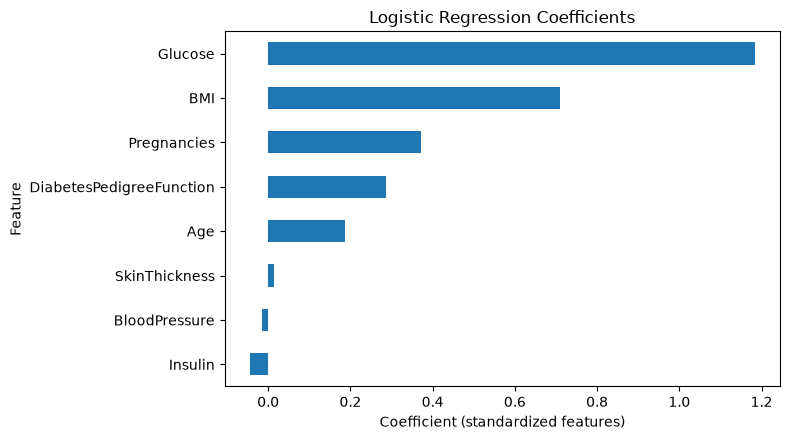

In [14]:
feature_names = X.columns
coefficients = model.named_steps["logistic_regression"].coef_[0]
coef_df = pd.DataFrame({"Feature":feature_names,"Coefficient":coefficients}).sort_values("Coefficient",ascending=False)
display(coef_df.round(4))

fig, ax = plt.subplots(figsize=(8,4.5))
coef_df.sort_values("Coefficient").plot(kind="barh", x="Feature", y="Coefficient", ax=ax, legend=False)
ax.set_title("Logistic Regression Coefficients")
ax.set_xlabel("Coefficient (standardized features)")
plt.tight_layout()
plt.show()

## 8. Key Findings
- ROC-AUC is about **0.813**.
- Recall is about **0.704**, so about 70.4% of positive cases in the fixed test split are detected.
- Glucose and BMI have the strongest positive coefficients in the fitted model.
- The confusion matrix contains 75 true negatives, 25 false positives, 16 false negatives, and 38 true positives.
- Recall is important in a screening-style classification task because false negatives represent missed positive cases.

### Limitation
This small historical dataset represents a specific population. The model is suitable for learning classification concepts, **not for medical diagnosis**.

### Conclusion
The balanced Logistic Regression pipeline demonstrates a complete binary-classification workflow on the supplied dataset. It achieves useful class-separation performance while still missing some positive cases, illustrating both the usefulness and limitations of the model.